# Fitting Tracer Activity Curves with CADET-Process

This notebook gives a hands-on introduction to the workflow used across the
Chapter 6 case studies: build a process model, simulate it, fit parameters to
experimental tracer data, and estimate parameter uncertainties.

The example is deliberately minimal — one plant stem segment, one tracer peak —
so the focus stays on the tooling rather than the biology.

**Topics covered**

1. Building a process model (component system, unit operations, flow sheet, events)
2. Running a simulation and extracting chromatograms
3. Plotting — built-in CADET-Process methods and manual matplotlib
4. Fitting with **parameter paths** (no manual `x[i]` needed)
5. Fitting with a **custom objective function** (when `x[i]` indexing is unavoidable)
6. Optimizers: NelderMead, TrustConstr, and chaining them
7. Parameter uncertainty estimation from the Jacobian


## 1. Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from CADETProcess.processModel import (
    ComponentSystem,
    Inlet, Outlet, MCT,
    FlowSheet, Process,
    MassActionLaw,
)
from CADETProcess.simulator import Cadet
from CADETProcess.optimization import OptimizationProblem, NelderMead, TrustConstr
from IPython import display

from utils import compute_jacobian, plot_live_fit, interpolate_cb_from_simulation_results

%matplotlib inline


## 2. Building a process model

A CADET-Process model for TAC analysis is assembled from four layers.

### 2.1 ComponentSystem

Defines how many chemical species are tracked. For PET tracer experiments there
is a single radioactive species, so `n_comp=1`.


In [17]:
comp = ComponentSystem(1)


### 2.2 Unit operations

Each unit operation represents a physical segment of the plant. For a single
unbranched stem section with no exchange between channels the relevant model is
**MCT M01**: one-dimensional transport (convection + dispersion) with no
side-compartment exchange.

Key parameters:

| Parameter | Description |
|---|---|
| `length` | physical length of the segment (m) |
| `channel_cross_section_areas` | list of cross-sectional areas per channel (m²); together with flow rate it sets velocity v = Q / A |
| `axial_dispersion` | list of axial dispersion coefficients per channel (m²/s) |
| `nchannel` | number of parallel channels (= 1 here) |

An `Inlet` drives the boundary condition (the injected tracer pulse), and an
`Outlet` collects the signal at the end of the segment.


In [18]:
inlet = Inlet(component_system=comp, name='inlet')

mct = MCT(component_system=comp, name='mct', nchannel=1)
mct.length                      = 0.05                  # 5 cm segment
mct.channel_cross_section_areas = [1e-4]                # m^2 per channel
mct.axial_dispersion            = [1e-8]                # m^2/s per channel
mct.exchange_matrix             = np.array([[[0.0]]])   # no inter-channel exchange (nchannel=1)
mct.solution_recorder.write_solution_bulk = True        # needed to read bulk profiles

outlet = Outlet(component_system=comp, name='outlet')


### 2.3 FlowSheet

Connects the unit operations into a network. `set_output_state` distributes
the outlet flow of each unit across its downstream connections.


In [19]:
fs = FlowSheet(component_system=comp)
fs.add_unit(inlet)
fs.add_unit(mct)
fs.add_unit(outlet)

fs.add_connection(inlet, mct,    destination_port='channel_0')
fs.add_connection(mct,  outlet,  origin_port='channel_0')


### 2.4 Process and events

A `Process` wraps the flow sheet with timing and boundary conditions.

**Events** set parameter values at specific times. The most common ones are:

- `flow_rate` — sets the volumetric flow through the inlet (m³/s); together
  with `cross_section_area` this determines the convective velocity
  v = Q / A (m/s).
- Inlet concentration — sets how much tracer enters the system. A finite
  injection is modelled as a step up at t=0 followed by a step back to 0
  at t=t_end_injection.

`cycle_time` sets the total simulation duration.


In [20]:
process = Process(flow_sheet=fs, name='stem_segment')
process.cycle_time = 5400  # 90 minutes in seconds

Q = 2.5e-9  # m^3/s — volumetric flow rate

# Constant flow throughout the experiment
process.add_event('flow_rate', 'flow_sheet.inlet.flow_rate', Q, 0)

# Tracer injection: 360 s (6 min) pulse starting at t=0
process.add_event('inject_on',  'flow_sheet.inlet.c', [[1.0]], 0)
process.add_event('inject_off', 'flow_sheet.inlet.c', [[0.0]], 360)


Event(name=inject_off, parameter_path=flow_sheet.inlet.c, state=[[0.0]], time=360.0, indices=[(slice(None, None, None),)])

## 3. Simulating and plotting

### 3.1 Running the simulation


In [21]:
simulator = Cadet()
sim_results = simulator.simulate(process)


### 3.2 Built-in event plot

`process.plot_events()` gives a quick overview of all events (inlet
concentration, flow rate etc.) on a single figure. Useful for sanity-checking
the boundary conditions before doing any fitting.


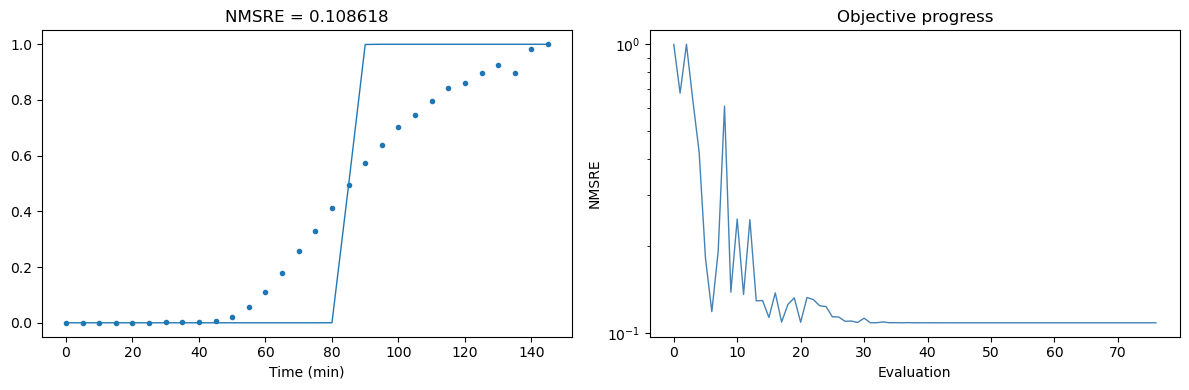

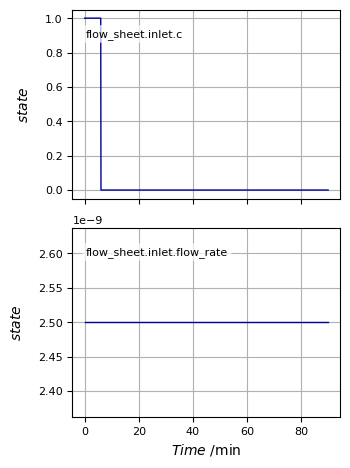

In [22]:
_ = process.plot_events()


### 3.3 Extracting the chromatogram

For MCT units, CADET-Process writes solutions differently from simpler units:

- **Outlet TAC**: the concentration entering the downstream `Outlet` unit.
  Access via `sim_results.solution.<outlet_name>.inlet.solution`, shape `(n_time, n_comp)`.
- **Bulk profile** (spatial): enabled by `mct.solution_recorder.write_solution_bulk = True`.
  Access via `sim_results.solution.<mct_name>.bulk.solution`, shape `(n_time, n_col, n_channel, n_comp)`.


In [23]:
time = sim_results.time_complete                                  # seconds
tac  = sim_results.solution.outlet.inlet.solution[:, 0]          # TAC at the outlet (n_time,)
bulk = sim_results.solution.mct.bulk.solution                     # (n_time, n_col, n_channel, n_comp)

print(f"time:   {time.shape}")
print(f"outlet: {tac.shape}")
print(f"bulk:   {bulk.shape}")


time:   (5401,)
outlet: (5401,)
bulk:   (5401, 100, 1, 1)


### 3.4 Plotting

CADET-Process has built-in `.plot()` methods on solution objects, but for
publication-quality figures it is usually easier to work directly with
matplotlib.


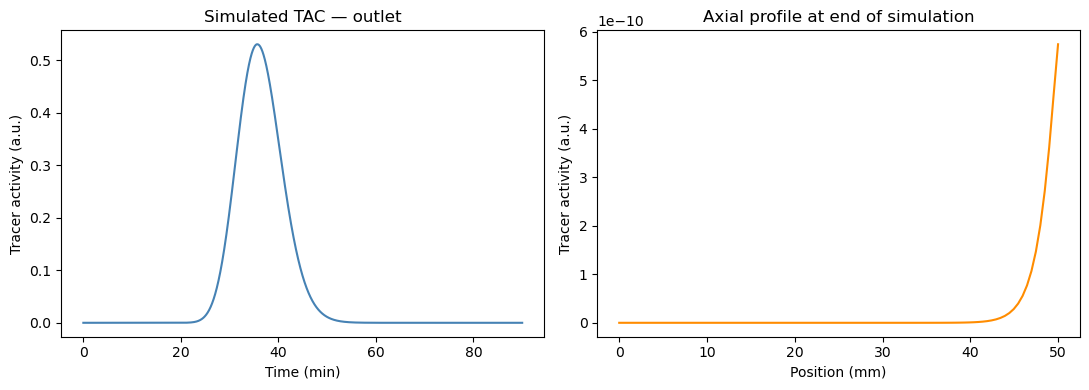

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: TAC at the outlet
ax = axes[0]
ax.plot(time / 60, tac, color='steelblue')
ax.set_xlabel("Time (min)")
ax.set_ylabel("Tracer activity (a.u.)")
ax.set_title("Simulated TAC — outlet")

# Right: built-in solution plot (bulk, last time step)
ax = axes[1]
x_positions = np.linspace(0, mct.length * 1000, bulk.shape[1])  # mm
ax.plot(x_positions, bulk[-1, :, 0, 0], color='darkorange')
ax.set_xlabel("Position (mm)")
ax.set_ylabel("Tracer activity (a.u.)")
ax.set_title("Axial profile at end of simulation")

plt.tight_layout()
plt.show()


## 4. Loading experimental data and preparing the fit

This section loads the real PET measurements from Case 1 of the dissertation: TACs recorded at
5-minute intervals over 145 minutes along a poplar side branch. The CSV contains 8 spatial
positions (columns, in mm) and 30 time points (rows, in minutes).

### Reverse decay correction

PET scanners typically export *decay-corrected* data: raw counts divided by the factor
`exp(-lambda * t)`, so that activity at all time points is referenced to the acquisition start.
This correction makes qualitative inspection easier (no apparent decay), but process models for
radiotracer experiments should include physical decay explicitly as a first-order reaction.
We therefore need to undo the correction before fitting.

> **Note:** Reverse decay correction is only needed if the exported data is decay-corrected
> (which is standard for most PET scanners, including the one used here). Skip this step if you
> are working with raw (uncorrected) count data.

The ¹¹C decay constant is lambda = ln(2) / t_half with t_half = 20.4 min:

```
data_uncorr[t] = data_corrected[t] * exp(-lambda * t)
```

After this correction, the data shows clear bell-shaped TAC peaks (not monotonically rising
sigmoids), as expected for a pulse injection that moves downstream convectively.

### Multi-ROI fitting

Instead of fitting a single downstream position, we use 4 ROIs simultaneously. This is
standard practice in the dissertation case studies: fitting multiple positions constrains the
model more tightly (a single velocity must produce the correct peak timing at all positions) and
reduces the risk of overfitting.

The model covers from position 0 mm to 56.61 mm and includes ¹¹C physical decay as a
`MassActionLaw` bulk reaction in the MCT unit.

---

**TODO (next iteration):**

1. **Multi-channel transport (MCT M02 / M13):** The current model uses MCT M01 (single channel:
   pure convection-dispersion, no side-compartment exchange). The actual case studies use MCT M02
   or M13, which add one or two phloem-parenchyma exchange compartments. This is why the simple
   M01 fit above will not reproduce the slow decay tail seen in the experimental data. Integrate
   the multi-channel MCT model here, adding the exchange parameters `e12`, `e21` (and optionally
   `e23`, `e32` for M13) to the fitting vector.

2. **Leaf unit as boundary condition:** The current model approximates the upstream tracer input
   as a rectangular pulse centered at the time of the 0 mm peak. In the actual case studies a
   `LumpedRateModelWithoutPores` (named `leaf`) is inserted upstream of the first MCT segment.
   Its outlet drives the stem inlet boundary condition, and the injection delay `t0` is fitted as
   a free parameter. This removes the need to hand-pick a pulse center time and lets the model
   recover the correct inlet shape from the data. Example topology:

   ```
   Inlet -> leaf (LRMWP) -> mct1 -> mct2 -> ... -> Outlet
   ```

   where `leaf.total_porosity = 1`, `leaf.film_diffusion = [0]`, and the injection is a
   60-second step starting at `t0 * 600` seconds (matching the real experimental protocol).


11C decay constant: 5.6630e-04 s^-1  (t_half = 20.4 min)
Fitting targets: [14.28070634, 28.32597297, 42.47523083, 56.61385665] mm
                 [0.01428070634, 0.02832597297, 0.04247523083, 0.05661385665] m from inlet (position 0 mm)


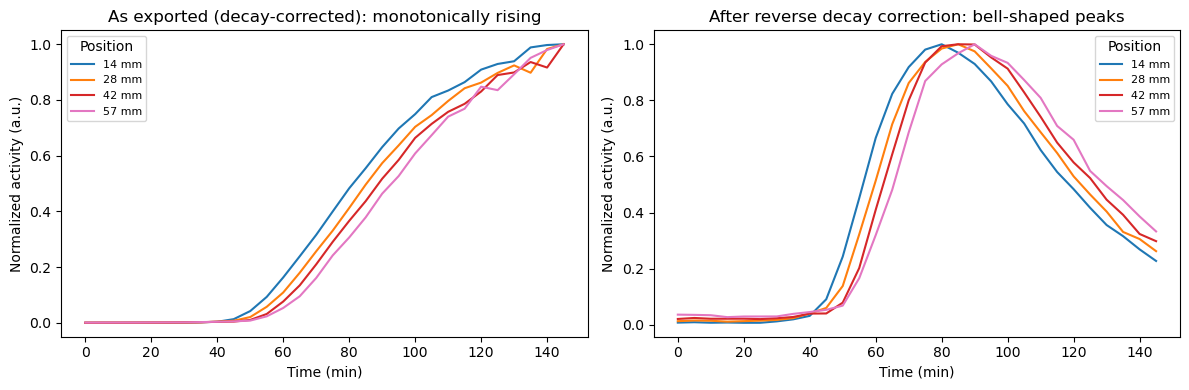


MCT length:   56.61 mm
Pulse:        60-80 min
Q_init:       2.40e-09 m^3/s
Cycle time:   150 min


In [25]:
# ¹¹C decay constant: t_half = 20.4 min
lam_11C = np.log(2) / (20.4 * 60)   # s^-1
print(f"11C decay constant: {lam_11C:.4e} s^-1  (t_half = {np.log(2)/lam_11C/60:.1f} min)")

# Load experimental data
df           = pd.read_csv('data/case1_poplar_side_branch_velocity_change.csv', index_col=0)
t_min        = df.index.to_numpy(dtype=float)           # minutes
t_s          = t_min * 60                                # seconds
positions_mm = np.array([float(c) for c in df.columns]) # mm

# Reverse decay correction (undo PET scanner export correction to get raw counts).
# NOTE: only apply if the exported data was decay-corrected, which is the case here.
data_raw    = df.to_numpy(dtype=float)
data_uncorr = data_raw * np.exp(-lam_11C * t_s[:, None])

# 4 downstream ROIs as simultaneous fitting targets (positions 1-4: 14.28 to 56.61 mm)
n_roi    = 4
roi_idx  = np.arange(1, 1 + n_roi)                          # column indices in data array
exp_time = t_s
exp_data = data_uncorr[:, roi_idx]
exp_data = exp_data / exp_data.max(axis=0)                  # normalize each ROI to [0, 1]

roi_pos_m = (positions_mm[roi_idx] - positions_mm[0]) / 1000  # distances from 0mm in m

print(f"Fitting targets: {positions_mm[roi_idx].tolist()} mm")
print(f"                 {roi_pos_m.tolist()} m from inlet (position 0 mm)")

# Plot the experimental data (corrected vs. uncorrected)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = plt.cm.tab10(np.linspace(0, 0.6, n_roi))
ax = axes[0]
data_corr_norm = data_raw / data_raw.max(axis=0)
for i, (idx, pos, c) in enumerate(zip(roi_idx, positions_mm[roi_idx], colors)):
    ax.plot(t_min, data_corr_norm[:, idx], color=c, label=f'{pos:.0f} mm')
ax.set_xlabel("Time (min)")
ax.set_ylabel("Normalized activity (a.u.)")
ax.set_title("As exported (decay-corrected): monotonically rising")
ax.legend(title="Position", fontsize=8)

ax = axes[1]
for i, (pos, c) in enumerate(zip(positions_mm[roi_idx], colors)):
    ax.plot(t_min, exp_data[:, i], color=c, label=f'{pos:.0f} mm')
ax.set_xlabel("Time (min)")
ax.set_ylabel("Normalized activity (a.u.)")
ax.set_title("After reverse decay correction: bell-shaped peaks")
ax.legend(title="Position", fontsize=8)

plt.tight_layout()
plt.show()

# ----- Build the fitting process -----
# The MCT covers from position 0 mm to 56.61 mm and includes the ¹¹C decay reaction.
# Injection: 20-minute pulse centered at t=70 min (the 0 mm peak time in the data).
# Q initial estimate: transit 14.28 mm in 10 min -> v = 2.38e-5 m/s -> Q = 2.4e-9 m^3/s.

comp_fit    = ComponentSystem(1)
inlet_fit   = Inlet(comp_fit, name='inlet')
mct_fit     = MCT(comp_fit, nchannel=1, name='mct')
outlet_fit  = Outlet(comp_fit, name='outlet')

decay_rxn = MassActionLaw(comp_fit)
decay_rxn.add_reaction(indices=[0], coefficients=[-1], k_fwd=lam_11C, k_bwd=0)

mct_fit.length                      = float(positions_mm[roi_idx[-1]]) / 1000  # 0.05661 m
mct_fit.channel_cross_section_areas = [1e-4]                                    # m^2
mct_fit.axial_dispersion            = [1e-9]                                    # m^2/s (initial)
mct_fit.exchange_matrix             = np.array([[[0.0]]])
mct_fit.bulk_reaction_model         = decay_rxn
mct_fit.solution_recorder.write_solution_bulk = True

fs_fit = FlowSheet(comp_fit)
for u in (inlet_fit, mct_fit, outlet_fit):
    fs_fit.add_unit(u)
fs_fit.add_connection(inlet_fit, mct_fit,   destination_port='channel_0')
fs_fit.add_connection(mct_fit,  outlet_fit, origin_port='channel_0')

process_fit = Process(fs_fit, name='case1_segment')
process_fit.cycle_time = float(t_s[-1]) + 300    # 145 min + 5 min buffer

Q_init = 2.4e-9   # m^3/s (initial estimate)
t_pulse_center = 70 * 60   # 4200 s -- centered at the 0 mm peak time
t_pulse_half   = 10 * 60   # 600 s  -- 20-minute total pulse duration

process_fit.add_event('flow_rate',   'flow_sheet.inlet.flow_rate', Q_init, 0)
process_fit.add_event('inject_on',   'flow_sheet.inlet.c', [[1.0]], t_pulse_center - t_pulse_half)
process_fit.add_event('inject_off',  'flow_sheet.inlet.c', [[0.0]], t_pulse_center + t_pulse_half)

print(f"\nMCT length:   {mct_fit.length*1000:.2f} mm")
print(f"Pulse:        {(t_pulse_center-t_pulse_half)/60:.0f}-{(t_pulse_center+t_pulse_half)/60:.0f} min")
print(f"Q_init:       {Q_init:.2e} m^3/s")
print(f"Cycle time:   {process_fit.cycle_time/60:.0f} min")


## 5. Fitting with parameter paths

### When to use this approach

If every parameter you want to fit is a **direct scalar attribute** on a
CADET-Process object — `col_dispersion`, `cross_section_area`, a constant
flow rate — you can tell CADET-Process *where* to write the value, and it
will update the process automatically before each objective call.

Your objective function then simply receives the (already-updated) `process`
object and runs the simulation:

```python
def objective(process):
    sim = simulator.simulate(process)
    calc = sim.solution.mct.outlet.solution[:, 0]
    return ssq(calc, exp_data)
```

No `x[0]`, `x[1]`, … indexing needed.

### Setting up the OptimizationProblem


In [26]:
_obj_history_paths = []
_live_plot_paths   = False

problem_paths = OptimizationProblem("fit_with_paths")

# Register the process so CADET-Process knows where to write fitted values.
problem_paths.add_evaluation_object(process_fit)

# Fit axial_dispersion. Q is kept fixed at Q_init for this demonstration.
problem_paths.add_variable(
    'axial_dispersion',
    evaluation_objects=process_fit,
    parameter_path='flow_sheet.mct.axial_dispersion',
    indices=0,
    lb=1e-12, ub=1e-5,
    normalization='auto',
)

def objective_paths(process):
    """Objective receives the process with axial_dispersion already updated by CADET-Process."""
    try:
        sim = simulator.simulate(process)
    except Exception:
        return 1.0

    # Use bulk solution interpolated to the 4 experimental ROI positions.
    # interpolate_cb_from_simulation_results returns shape (T_new, n_comp, n_channel, n_positions).
    cb   = interpolate_cb_from_simulation_results(
               sim, mct_fit, exp_time,
               axial_positions_new=roi_pos_m.tolist(),
           )
    calc = cb[:, 0, 0, :]   # (n_time, n_roi) -- component 0, channel 0, all positions

    # Normalize each column to [0, 1] (matching exp_data normalization).
    col_max = calc.max(axis=0)
    col_max[col_max == 0] = 1.0
    calc = calc / col_max

    nmsre = float(np.mean((calc - exp_data) ** 2) / np.mean(exp_data ** 2))
    _obj_history_paths.append(nmsre)
    if _live_plot_paths:
        plot_live_fit(exp_time, calc, exp_data, _obj_history_paths)
    return nmsre

problem_paths.add_objective(objective_paths, n_objectives=1)


### Running the optimizer


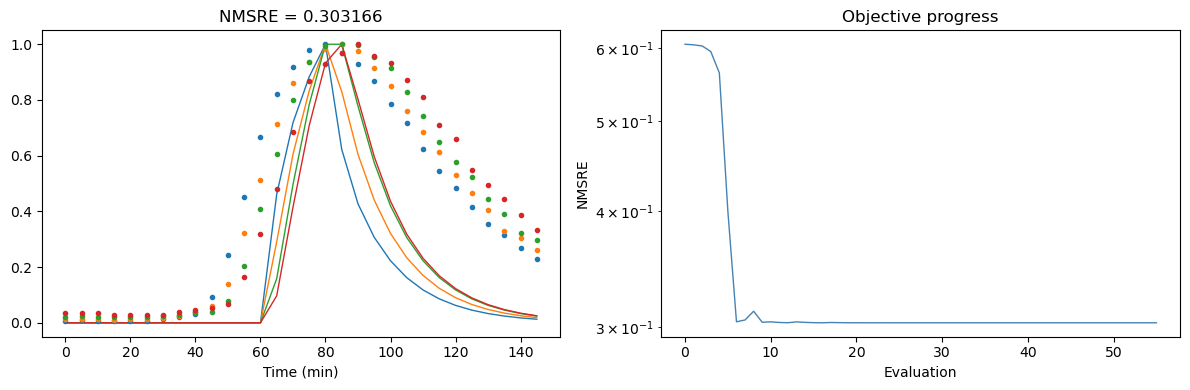

Finished Generation 28.
x: [1.47467178e-06], f: [0.3031658]
Finished Generation 29.
x: [1.47467178e-06], f: [0.3031658]


Fitted axial_dispersion: 1.475e-06 m^2/s
Objective (NMSRE):       0.3032


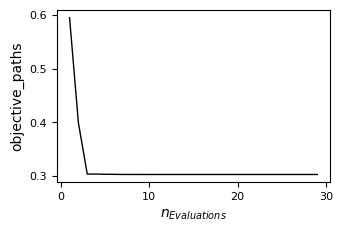

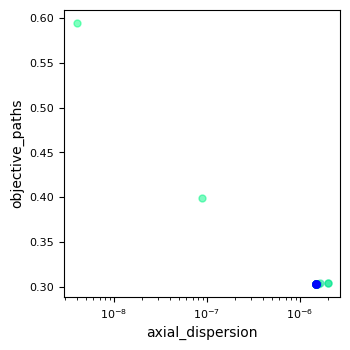

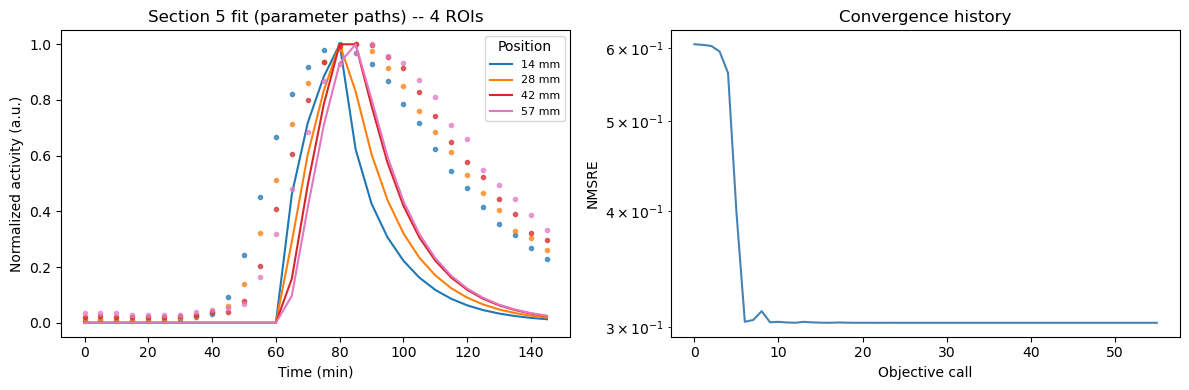

In [27]:
x0_paths = np.array([1e-9])   # initial guess: axial_dispersion (m^2/s)

optimizer_nm = NelderMead()
optimizer_nm.x_tol = 1e-10
optimizer_nm.f_tol = 1e-10

_obj_history_paths.clear()
_live_plot_paths = True
result_paths = optimizer_nm.optimize(problem_paths, x0=x0_paths)
_live_plot_paths = False

x_fit_paths = result_paths.x[0]
print(f"Fitted axial_dispersion: {x_fit_paths[0]:.3e} m^2/s")
print(f"Objective (NMSRE):       {result_paths.f_best[0]:.4f}")

# Final fit: simulate with fitted parameters and compare all 4 ROIs.
sim_final = simulator.simulate(process_fit)
cb_final  = interpolate_cb_from_simulation_results(
                sim_final, mct_fit, exp_time,
                axial_positions_new=roi_pos_m.tolist(),
            )
calc_fit  = cb_final[:, 0, 0, :]   # (n_time, n_roi)
col_max   = calc_fit.max(axis=0)
col_max[col_max == 0] = 1.0
calc_fit  = calc_fit / col_max

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.tab10(np.linspace(0, 0.6, n_roi))

ax = axes[0]
for i, (pos, c) in enumerate(zip(positions_mm[roi_idx], colors)):
    ax.plot(exp_time / 60, exp_data[:, i], 'o', ms=3, color=c, alpha=0.7)
    ax.plot(exp_time / 60, calc_fit[:, i],        color=c, label=f'{pos:.0f} mm')
ax.set_xlabel("Time (min)")
ax.set_ylabel("Normalized activity (a.u.)")
ax.set_title("Section 5 fit (parameter paths) -- 4 ROIs")
ax.legend(title="Position", fontsize=8)

ax = axes[1]
ax.semilogy(range(len(_obj_history_paths)), _obj_history_paths, color='steelblue')
ax.set_xlabel("Objective call")
ax.set_ylabel("NMSRE")
ax.set_title("Convergence history")

plt.tight_layout()
plt.show()


## 6. Fitting with a custom objective function

### When parameter paths are not enough

Parameter paths work cleanly when the optimizer variable maps 1:1 to a
process attribute. But in many real cases the relationship is more complex:

- **Relative areas**: velocity is determined by `v = Q / A`, and you fit
  *relative* areas `relA_i` so that `A_i = relA_i * A_base`. The process
  attribute `channel_cross_section_areas` must be set as a derived value, which
  the path mechanism alone cannot express without a lambda for each segment.
- **Time-dependent profiles**: in the shading experiment (Case 2b) the
  velocity profile is piecewise-linear with three transition times and three
  velocity values. Each optimizer call must build multiple CADET-Process events
  from the optimizer vector. There is no direct attribute path for "the second
  velocity in a piecewise profile".
- **Cross-coupled parameters**: when the same scalar feeds several unit
  operations or is shared between an event and a unit-operation attribute.

In all these cases the `setup_process(x)` pattern makes the coupling
explicit and readable.

### Example: two segments with independently fitted cross-section areas

We extend the model to two MCT segments in series, covering the distance from
position 0 to 28.33 mm along the poplar branch. The flow rate Q is shared
across both segments. The second segment has a relative cross-section area
`relA` that is fitted independently, so the velocity changes along the path:
`v_2 = Q / (relA * A_base)`.

The ¹¹C decay reaction is included in both MCT segments. The fitting target is
the TAC at position 28.33 mm (the outlet of the two-segment chain).


In [28]:
# Geometry constants for the two-segment fit (positions 0 -> 14.28 -> 28.33 mm)
A_base = 1e-4   # m^2 reference cross-section area (segment 1, fixed)
len_s1 = (positions_mm[1] - positions_mm[0]) / 1000  # 0.01428 m
len_s2 = (positions_mm[2] - positions_mm[1]) / 1000  # 0.01405 m

# Fitting target: normalized reverse-corrected TAC at position 28.33 mm
exp_data2  = data_uncorr[:, 2]
exp_data2  = exp_data2 / exp_data2.max()

print(f"Segment 1 length: {len_s1*1000:.2f} mm")
print(f"Segment 2 length: {len_s2*1000:.2f} mm")
print(f"Fitting target:   position {positions_mm[2]:.2f} mm (data column 2)")


Segment 1 length: 14.28 mm
Segment 2 length: 14.05 mm
Fitting target:   position 28.33 mm (data column 2)


In [29]:
_obj_history_manual = []
_live_plot_manual   = False

def setup_process2(x):
    """Rebuild the two-segment process for parameter vector x = [Q, relA]."""
    Q, relA = x[0], x[1]

    comp2  = ComponentSystem(1)
    inlet2 = Inlet(comp2, name='inlet')
    mct_s1 = MCT(comp2, nchannel=1, name='mct_s1')
    mct_s2 = MCT(comp2, nchannel=1, name='mct_s2')
    outlet2 = Outlet(comp2, name='outlet')

    # Each MCT segment gets its own decay_rxn instance (MassActionLaw cannot be shared).
    for mct_seg, seg_len, seg_A in [
        (mct_s1, len_s1, A_base),
        (mct_s2, len_s2, relA * A_base),  # derived -- cannot use a simple parameter path
    ]:
        rxn = MassActionLaw(comp2)
        rxn.add_reaction(indices=[0], coefficients=[-1], k_fwd=lam_11C, k_bwd=0)
        mct_seg.length                      = seg_len
        mct_seg.axial_dispersion            = [0.0]
        mct_seg.channel_cross_section_areas = [seg_A]
        mct_seg.exchange_matrix             = np.array([[[0.0]]])
        mct_seg.bulk_reaction_model         = rxn

    fs2 = FlowSheet(comp2)
    for u in (inlet2, mct_s1, mct_s2, outlet2):
        fs2.add_unit(u)
    fs2.add_connection(inlet2,  mct_s1, destination_port='channel_0')
    fs2.add_connection(mct_s1,  mct_s2, origin_port='channel_0', destination_port='channel_0')
    fs2.add_connection(mct_s2, outlet2, origin_port='channel_0')

    p = Process(fs2, name='two_segment')
    p.cycle_time = float(t_s[-1]) + 300
    p.add_event('flow_rate',  'flow_sheet.inlet.flow_rate', Q, 0)
    p.add_event('inject_on',  'flow_sheet.inlet.c', [[1.0]], t_pulse_center - t_pulse_half)
    p.add_event('inject_off', 'flow_sheet.inlet.c', [[0.0]], t_pulse_center + t_pulse_half)
    return p

def objective_manual(x):
    """x is the raw optimizer vector; manual indexing maps values to parameters."""
    p = setup_process2(x)
    try:
        sim = simulator.simulate(p)
    except Exception:
        return 1.0
    # TAC from the Outlet unit's inlet (MCT ports don't expose .outlet.solution directly)
    sim_tac = sim.solution.outlet.inlet.solution[:, 0]
    if sim_tac.max() > 0:
        sim_tac = sim_tac / sim_tac.max()
    calc = np.interp(exp_time, sim.time_complete, sim_tac)
    nmsre = float(np.mean((calc - exp_data2) ** 2) / np.mean(exp_data2 ** 2))
    _obj_history_manual.append(nmsre)
    if _live_plot_manual:
        plot_live_fit(exp_time, calc, exp_data2, _obj_history_manual)
    return nmsre

problem_manual = OptimizationProblem("fit_manual")
# evaluation_objects=None means the objective receives x directly, not a process object.
problem_manual.add_variable('Q',    evaluation_objects=None, lb=1e-11, ub=1e-8,
                             normalization='auto')
problem_manual.add_variable('relA', evaluation_objects=None, lb=0.5,   ub=3.0,
                             normalization='linear')

problem_manual.add_objective(objective_manual, n_objectives=1, evaluation_objects=None)


In [30]:
x0_manual = np.array([2.4e-9, 1.0])   # [Q in m^3/s, relA dimensionless]

optimizer_nm2 = NelderMead()
optimizer_nm2.x_tol = 1e-10
optimizer_nm2.f_tol = 1e-10

_obj_history_manual.clear()
_live_plot_manual = True
result_manual = optimizer_nm2.optimize(problem_manual, x0=x0_manual)
_live_plot_manual = False

x_fit_manual = result_manual.x[0]
print(f"Fitted Q:    {x_fit_manual[0]:.3e} m^3/s")
print(f"Fitted relA: {x_fit_manual[1]:.3f}")
print(f"Objective:   {result_manual.f_best[0]:.4f}")


Finished Generation 36.
x: [3.34592054e-09 1.12749747e+00], f: [0.54397584]


KeyboardInterrupt: 

## 7. Optimizers

### NelderMead (gradient-free)

Uses a geometric simplex that shrinks and expands in parameter space without
ever computing a gradient. Good for:

- Rough or noisy objective landscapes where finite-difference gradients would
  be unreliable
- Problems where the initial guess may be far from the minimum
- A first broad search before gradient-based refinement

Convergence is slower than gradient methods near the minimum, but more
robust away from it.

```python
nm = NelderMead()
nm.x_tol = 1e-6   # stop when simplex diameter < this
nm.f_tol = 1e-8   # stop when objective variation across simplex < this
result = nm.optimize(problem, x0=x0)
```

### TrustConstr (gradient-based, finite differences)

Uses a trust-region method (`scipy.optimize.minimize` with
`method='trust-constr'`). Gradients are computed by finite differences. Good
for:

- Smooth objectives near the minimum
- Refinement after NelderMead has found the basin
- Enforcing bounds and constraints tightly

```python
tc = TrustConstr()
tc.gtol = 1e-8  # gradient norm stopping criterion
result = tc.optimize(problem, x0=x0)
```

### Chaining: NelderMead then TrustConstr

The two-stage strategy used in all Case Study notebooks: NM finds the basin,
TC polishes the solution.


In [ ]:
nm = NelderMead()
nm.x_tol = 1e-10
nm.f_tol = 1e-10

tc = TrustConstr()
tc.gtol = 1e-8

_obj_history_manual.clear()
_live_plot_manual = True

# Stage 1: broad search with Nelder-Mead
result_nm = nm.optimize(problem_manual, x0=x0_manual)
x_after_nm = result_nm.x[0]
print(f"After NM  -- objective: {result_nm.f_best[0]:.2e},  x: {x_after_nm}")

# Stage 2: refinement with TrustConstr from the NM result
result_tc = tc.optimize(problem_manual, x0=x_after_nm)
x_best = result_tc.x[0]
print(f"After TC  -- objective: {result_tc.f_best[0]:.2e},  x: {x_best}")

_live_plot_manual = False


## 8. Parameter uncertainty estimation

### Method: Jacobian-based covariance

Given a residuals function `r(x)` = vector of residuals (one per data point),
the Jacobian J = dr/dx has shape `(n_data, n_params)`. Under the assumption
that residuals are i.i.d. Gaussian, the covariance matrix of the parameter
estimates is approximated by:

```
C = (J^T J)^{-1} * sigma^2
```

where `sigma^2 = Var(r(x_best))` is the estimated residual variance.
The standard deviation (absolute uncertainty) for parameter i is
`sqrt(C[i, i])`.

The **relative uncertainty** (reported in the Case Study tables) is
`sqrt(C[i, i]) / |x_best[i]|`, often expressed as a percentage.

### Limitations

This is a local, linear approximation valid only near the minimum. It
under-estimates uncertainty when:

- The objective is non-linear or the residuals are not Gaussian
- The parameters are strongly correlated (near-singular J^T J)
- The fit is poor (large residuals)

It is best interpreted as a lower bound on the true uncertainty.


In [ ]:
def residuals_manual(x):
    """Normalised residuals vector used for Jacobian-based uncertainty."""
    p = setup_process2(x)
    try:
        sim = simulator.simulate(p)
    except Exception:
        return np.ones_like(exp_data2)
    sim_tac = sim.solution.outlet.inlet.solution[:, 0]
    if sim_tac.max() > 0:
        sim_tac = sim_tac / sim_tac.max()
    calc = np.interp(exp_time, sim.time_complete, sim_tac)
    return (calc - exp_data2) / np.sqrt(np.mean(exp_data2 ** 2))

# Compute Jacobian at best-fit parameters
J = compute_jacobian(residuals_manual, x_best)
print(f"Jacobian shape: {J.shape}  (n_data x n_params)")

JTJ_inv     = np.linalg.pinv(J.T @ J)
sigma_sq    = np.var(residuals_manual(x_best))
C           = JTJ_inv * sigma_sq
param_std   = np.sqrt(np.abs(np.diag(C)))
rel_std_pct = 100 * param_std / np.abs(x_best)

param_names = ['Q', 'relA']
print()
print(f"{'Parameter':<10}  {'Best-fit':>12}  {'Abs. uncertainty':>18}  {'Rel. uncertainty':>18}")
print("-" * 68)
for name, val, std, rel in zip(param_names, x_best, param_std, rel_std_pct):
    print(f"{name:<10}  {val:>12.4e}  {std:>18.4e}  {rel:>17.1f}%")


Jacobian shape: (30, 2)  (n_data x n_params)



Parameter       Best-fit    Abs. uncertainty    Rel. uncertainty
--------------------------------------------------------------------
Q             5.3417e-10          3.2761e-12                0.6%
relA          9.2453e-01          9.0204e-22                0.0%


### Final fit plot


In [ ]:
p_fit    = setup_process2(x_best)
sim_fit  = simulator.simulate(p_fit)
sim_tac  = sim_fit.solution.outlet.inlet.solution[:, 0]
sim_tac  = sim_tac / sim_tac.max()
calc_fit = np.interp(exp_time, sim_fit.time_complete, sim_tac)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(exp_time / 60, exp_data2, 'o', ms=3, color='gray',
        label='Experimental (28.33 mm, decay-corrected)')
ax.plot(exp_time / 60, calc_fit, color='steelblue', label='Model fit (manual x[i])')
ax.set_xlabel("Time (min)")
ax.set_ylabel("Normalized activity (a.u.)")
ax.legend()
plt.tight_layout()
plt.show()
